<a href="https://colab.research.google.com/github/Asfiashub/Mini-Projects/blob/main/Asfiashub/Mini-Projects/tree/main/MLML/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows of Features [[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
  1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
  6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
  1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
  4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02 7.864e-02 8.690e-02
  7.017e-02 1.812e-01 5.667e-02 5.435e-01 7.339e-01 3.398e+00 7.408e+01
  5.225e-03 1.308e-02 1.860e-02 1.340e-02 1.389e-02 3.532e-03 2.499e+01
  2.341e+01 1.588e+02 1.956e+03 1.238e-01 1.866e-01 2.416e-01 1.860e-01
  2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 1.203e+03 1.096e-01 1.599e-01 1.974e-01
  1.279e-01 2.069e-01 5.999e-02 7.456e-01 7.869e-01 4.585e+00 9.403e+01
  6.150e-03 4.006e-02 3.832e-02 2.058e-02 2.250e-02 4.571e-03 2.357e+01
  2.553e+01 1.525e+02 1.709e+03 1.444e-01 4.245e-01 4.504e-01 2.430e-01
  3.613e-01 8.758e-02]
 [1.142e+01 2.038e+01 7.758e+01 3.861e+02 

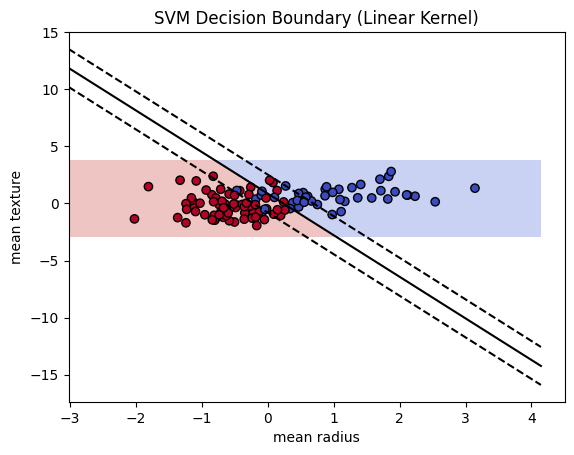

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
data = load_breast_cancer()
print("First 5 rows of Features",data.data[:5])
print("\n Features names",data.feature_names)
print("\n\n Target names",data.target_names)
X= data.data[:,[0,1]]
y=data.target
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
svm_classifier=SVC(kernel='linear',C=1.0,random_state=42)
svm_classifier.fit(x_train_scaled,y_train)
y_pred= svm_classifier.predict(x_test_scaled)
print(f"Svm accuracy: {accuracy_score(y_test,y_pred):.2f}")
print("Classification report:\n",classification_report(y_test,y_pred))
print("Confusion matrix:\n",confusion_matrix(y_test,y_pred))
# --- ADD THESE CHANGES TO YOUR PROGRAM ---
def plot_decision_boundary(X, y, model, scaler):
    h = .02
    X_min, X_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(X_min, X_max, h),
                         np.arange(y_min, y_max, h))

    # 1. Background color (Decision boundary regions)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

    # 2. Plot the separating hyperplane (Decision Boundary)
    w = model.coef_[0]
    a = -w[0] / w[1]
    x_line = np.linspace(X_min, X_max)
    y_line = a * x_line - (model.intercept_[0]) / w[1]
    plt.plot(x_line, y_line, 'k-', label="Hyperplane")

    # 3. Optional: Plot margins
    margin = 1 / np.sqrt(np.sum(model.coef_**2))
    yy_down = y_line - np.sqrt(1 + a**2) * margin
    yy_up = y_line + np.sqrt(1 + a**2) * margin
    plt.plot(x_line, yy_down, 'k--')
    plt.plot(x_line, yy_up, 'k--')

    # Scatter points
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
    plt.xlabel(data.feature_names[0])
    plt.ylabel(data.feature_names[1])
    plt.title('SVM Decision Boundary (Linear Kernel)')
    plt.show()

# Call the updated function
plot_decision_boundary(x_test_scaled, y_test, svm_classifier, scaler)


